#  Used Car Price Prediction 

**Goal:** Build a complete regression project from data cleaning to model training, tuning, saving, and Streamlit deployment.

**Target:** `price`

## Project Requirements

- Load a real-world dataset
- Handle missing values
- Remove duplicates
- Detect and handle outliers
- Encode categorical variables
- Scale numerical features where required
- Perform feature engineering
- Train at least 4 regression models
- Compare MAE, MSE, RMSE and R²
- Apply hyperparameter tuning
- Compare before vs after tuning
- Save the final model with Joblib
- Prepare the model for a Streamlit application


## 1.  Import Libraries

In [2]:
# If needed, uncomment and run:
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

import os
import warnings
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib
    
warnings.filterwarnings('ignore')

## 2. Load the dataset:

In [3]:
DATA_PATH = "vehicles.csv"
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


## 3. Understand the Dataset

Before cleaning anything, we need to understand what we actually have.

In [4]:
print('Rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes)

print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False).head(20))

Rows and columns: (426880, 26)

Column names:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']

Data types:


id                int64
url                 str
region              str
region_url          str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
VIN                 str
drive               str
size                str
type                str
paint_color         str
image_url           str
description         str
county          float64
state               str
lat             float64
long            float64
posting_date        str
dtype: object


Missing values:


county          426880
size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
lat               6549
long              6549
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
description         70
image_url           68
posting_date        68
dtype: int64

## 4. Basic Data Cleaning

We will first remove exact duplicate rows and inspect the target column.

In [6]:
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print(f'Duplicates removed: {before - after}')
print(f'New shape: {df.shape}')

print('\nPrice summary:')
display(df['price'].describe())


Duplicates removed: 0
New shape: (426880, 26)

Price summary:


count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

## 5. Removing Invalid Target Values

A car price of 0 or a negative price is not useful for this regression problem. We will inspect the data before removing invalid values.

In [7]:
if 'price' in df.columns:
    print('Prices <= 0:', (df['price'] <= 0).sum())
    print('Prices > 0:', (df['price'] > 0).sum())
    
    df = df[df['price'] > 0].copy()
    print('Shape after removing invalid prices:', df.shape)

Prices <= 0: 32895
Prices > 0: 393985
Shape after removing invalid prices: (393985, 26)


## 6. Inspect Outliers in Price

Real-world datasets can contain extreme values. We will visualize the target before deciding how to handle them.

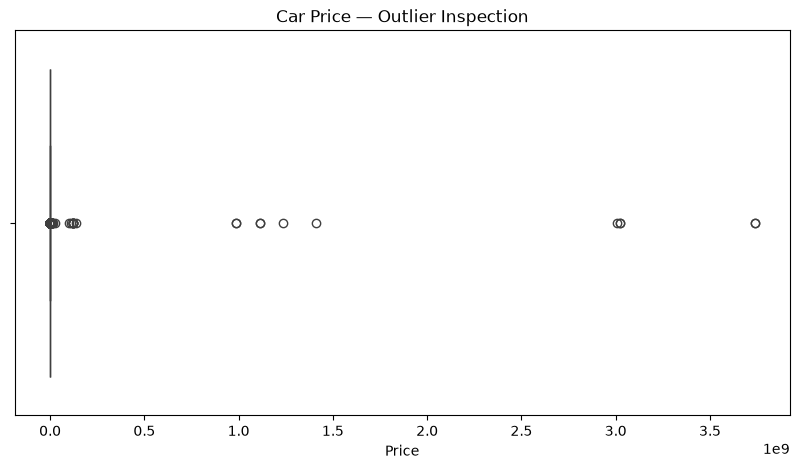

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Car Price — Outlier Inspection')
plt.xlabel('Price')
plt.show()

### Outlier rule for the practice project

We will use the IQR method on the target as a starting point. 

In [9]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('Lower bound:', lower)
print('Upper bound:', upper)
print('Potential outliers:', ((df['price'] < lower) | (df['price'] > upper)).sum())

Lower bound: -23885.0
Upper bound: 58475.0
Potential outliers: 7779


# **REMOVING OUTLIERS**:

In [10]:
before = len(df)

df = df[
    (df["price"] >= lower) &
    (df["price"] <= upper)
].copy()

after = len(df)

print("Outliers removed:", before - after)
print("New dataset shape:", df.shape)

Outliers removed: 7779
New dataset shape: (386206, 26)


## 7. Feature Selection

In [11]:
candidate_features = [
    'year', 'manufacturer', 'model', 'condition', 'cylinders',
    'fuel', 'odometer', 'title_status', 'transmission', 'drive',
    'size', 'type', 'paint_color', 'state'
]

features = [col for col in candidate_features if col in df.columns]

print('Features found in dataset:')
print(features)

missing_features = [col for col in candidate_features if col not in df.columns]
print('\nFeatures not found:')
print(missing_features)

Features found in dataset:
['year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']

Features not found:
[]


## 8. Feature Engineering

Instead of using the vehicle's year directly, we can create **vehicle age**. This is easier for a user to understand and can be useful for prediction.

In [12]:
if 'year' in df.columns:
    current_year = pd.Timestamp.now().year
    df['vehicle_age'] = current_year - df['year']
    df['vehicle_age'] = df['vehicle_age'].clip(lower=0)
    
    print('Created feature: vehicle_age')
    display(df[['year', 'vehicle_age']].head())

Created feature: vehicle_age


,year,vehicle_age
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


## 9. Prepare X and y

`X` contains the information used by the model. `y` contains the price we want to predict.

In [13]:
if 'vehicle_age' in df.columns:
    features = [col for col in features if col != 'year'] + ['vehicle_age']

X = df[features].copy()
y = df['price'].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
display(X.head())

X shape: (386206, 14)
y shape: (386206,)


,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,vehicle_age
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN


## 10. Train/Test Split

We keep a separate test set so that the final model is evaluated on data it did not see during training.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 308964
Testing samples: 77242


## 11. Preprocessing Pipeline

We will automatically:

- Fill missing numerical values with the median
- Fill missing categorical values with the most frequent category
- One-hot encode categorical variables
- Scale numerical variables

Using a pipeline helps prevent data leakage.

In [15]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('Numerical features:', numeric_features)
print('Categorical features:', categorical_features)

Numerical features: ['odometer', 'vehicle_age']
Categorical features: ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']


## 12. Train 4 Regression Models

We will compare four different approaches rather than assuming one model is best.

In [ ]:
MAX_ROWS = 30_000

if len(X_train) > MAX_ROWS:
    X_train_fast, _, y_train_fast, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_ROWS,
        random_state=42
    )
else:
    X_train_fast = X_train
    y_train_fast = y_train

print("Training rows used:", len(X_train_fast))

models = {
    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=3,
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=50,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
}

results = []
trained_pipelines = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train_fast, y_train_fast)

    # Still evaluate on the FULL test set
    predictions = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

    trained_pipelines[name] = pipe

    print(f"RMSE: {rmse:,.2f}")
    print(f"R²: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('RMSE')

display(results_df)

Training rows used: 30000

Training Linear Regression...
RMSE: 8,954.34
R²: 0.5128

Training Decision Tree...
RMSE: 7,651.96
R²: 0.6442

Training Random Forest...
RMSE: 6,610.67
R²: 0.7344

Training Gradient Boosting...
RMSE: 7,716.77
R²: 0.6381


,Model,MAE,MSE,RMSE,R2
2,Random Forest,4226.725385,4.370096e+07,6610.669964,0.734433
1,Decision Tree,4931.207664,5.855255e+07,7651.963920,0.644182
3,Gradient Boosting,5315.617112,5.954855e+07,7716.770954,0.638129
0,Linear Regression,5729.089589,8.018018e+07,8954.338797,0.512752


## 13. Model Comparison Visualization

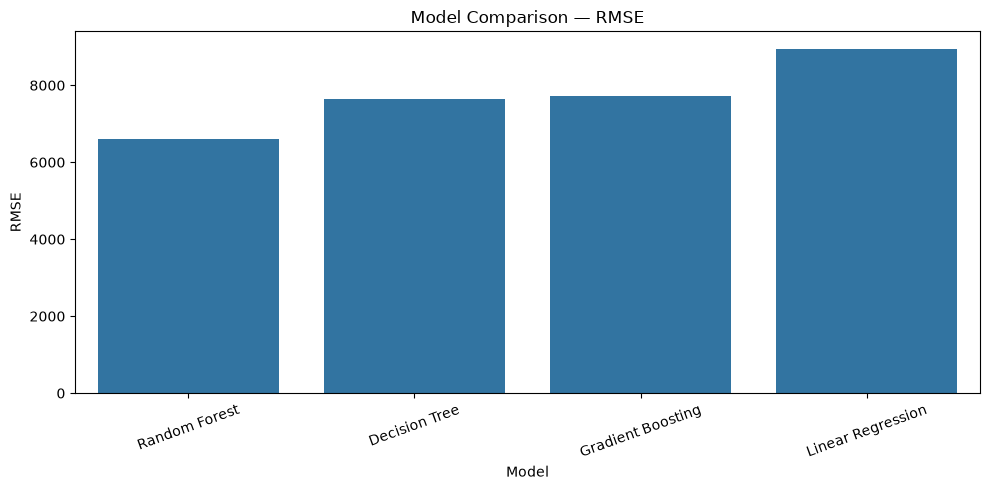

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='RMSE')
plt.xticks(rotation=20)
plt.title('Model Comparison — RMSE')
plt.tight_layout()
plt.show()

## 14. Hyperparameter Tuning

We will tune the Random Forest model using `GridSearchCV`.

> For the first practice run, use a small parameter grid. A larger grid can take much longer on this dataset.

In [19]:
from sklearn.model_selection import RandomizedSearchCV

MAX_TRAIN_ROWS = 25_000

if len(X_train) > MAX_TRAIN_ROWS:
    X_fit, _, y_fit, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_TRAIN_ROWS,
        random_state=42
    )
else:
    X_fit = X_train
    y_fit = y_train

print("Rows used for tuning:", len(X_fit))

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    'model__n_estimators': [30, 50],
    'model__max_depth': [16, 24],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

tuning = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=3,
    cv=2,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

tuning.fit(X_fit, y_fit)

print("\nBest parameters:")
print(tuning.best_params_)

print("\nBest CV RMSE:")
print(-tuning.best_score_)

best_model = tuning.best_estimator_

Rows used for tuning: 25000
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Best parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 16}

Best CV RMSE:
7036.883804245112


## 15. Evaluate the Tuned Model

In [20]:
tuned_predictions = best_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_mse = mean_squared_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_predictions)

tuned_results = pd.DataFrame([{
    'Model': 'Tuned Random Forest',
    'MAE': tuned_mae,
    'MSE': tuned_mse,
    'RMSE': tuned_rmse,
    'R2': tuned_r2
}])

display(tuned_results)

,Model,MAE,MSE,RMSE,R2
0,Tuned Random Forest,4378.877333,4.543224e+07,6740.344332,0.723912


## 16. Before vs After Tuning

Compare the original Random Forest with the tuned version using the same test set.

In [21]:
before_tuning = results_df[results_df['Model'] == 'Random Forest'].copy()
before_tuning['Model'] = 'Random Forest — Before Tuning'

comparison = pd.concat([
    before_tuning[['Model', 'MAE', 'MSE', 'RMSE', 'R2']],
    tuned_results
], ignore_index=True)

display(comparison)

,Model,MAE,MSE,RMSE,R2
0,Random Forest — Before Tuning,4226.725385,4.370096e+07,6610.669964,0.734433
1,Tuned Random Forest,4378.877333,4.543224e+07,6740.344332,0.723912


## 17. Save the Final Model

In [22]:
os.makedirs('models', exist_ok=True)

MODEL_PATH = 'models/used_car_price_model.joblib'
joblib.dump(best_model, MODEL_PATH)

print(f'Model saved to: {MODEL_PATH}')

Model saved to: models/used_car_price_model.joblib


## 18. Test the Saved Model

Load the saved model and make sure it can still predict.

In [23]:
loaded_model = joblib.load(MODEL_PATH)
    
test_predictions = loaded_model.predict(X_test.head(5))
    
display(pd.DataFrame({
    'Actual Price': y_test.head(5).values,
    'Predicted Price': test_predictions
}))

,Actual Price,Predicted Price
0,2000,25979.102489
1,32295,27818.438972
2,3500,3927.050204
3,2995,7432.996823
4,6500,9647.110569


## 19A. Final Model for Streamlit

In [28]:

best_model = tuning.best_estimator_

print("Final model prepared successfully.")
print(type(best_model.named_steps["model"]).__name__)

Final model prepared successfully.
RandomForestRegressor


## 19B. Feature Importance

In [29]:

fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_forest = best_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = fitted_forest.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 features:")
display(importance_df.head(20))


Top 20 features:


,Feature,Importance
0,num__vehicle_age,0.444267
1,num__odometer,0.125967
2,cat__cylinders_4 cylinders,0.060503
3,cat__drive_fwd,0.054042
4,cat__fuel_diesel,0.053244
5,cat__cylinders_8 cylinders,0.026843
6,cat__type_sedan,0.020039
7,cat__fuel_gas,0.015041
8,cat__type_pickup,0.010889
9,cat__type_truck,0.007171


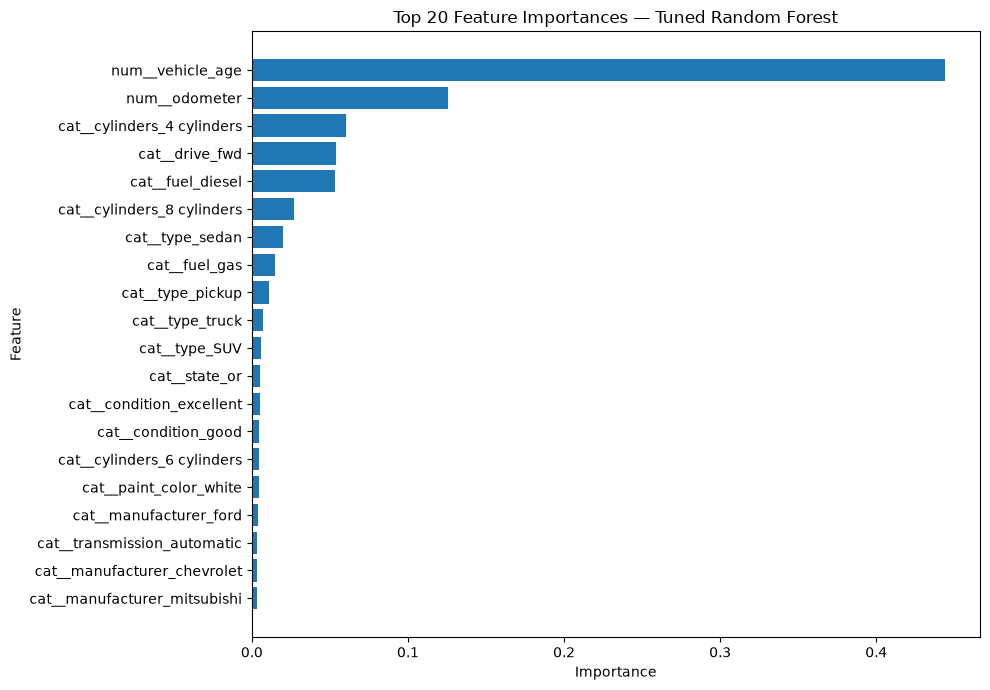

In [30]:
# Visualize top feature importances

top_n = 20
top_importance_df = importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance_df["Feature"],
    top_importance_df["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances — Tuned Random Forest")
plt.tight_layout()
plt.show()


## 19. Export Streamlit Artifacts



In [33]:

os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# Final model
MODEL_PATH = "models/used_car_price_model.joblib"
joblib.dump(best_model, MODEL_PATH)

# Model comparison
results_df.to_csv(
    "artifacts/results.csv",
    index=False
)

# Before vs after tuning
comparison.to_csv(
    "artifacts/comparison.csv",
    index=False
)

# Feature importance
importance_df.to_csv(
    "artifacts/feature_importance.csv",
    index=False
)

# Reference year used by the model's feature engineering
reference_year = pd.Timestamp.now().year

pd.DataFrame({
    "reference_year": [reference_year]
}).to_csv(
    "artifacts/reference_year.csv",
    index=False
)

print("✅ Streamlit artifacts exported successfully!")
print()
print("Created:")
print("✓ models/used_car_price_model.joblib")
print("✓ artifacts/results.csv")
print("✓ artifacts/comparison.csv")
print("✓ artifacts/feature_importance.csv")
print("✓ artifacts/reference_year.csv")


✅ Streamlit artifacts exported successfully!

Created:
✓ models/used_car_price_model.joblib
✓ artifacts/results.csv
✓ artifacts/comparison.csv
✓ artifacts/feature_importance.csv
✓ artifacts/reference_year.csv


## 19D. Verify Streamlit Files

Run this final check before opening the Streamlit application.


In [34]:

required_files = [
    "models/used_car_price_model.joblib",
    "artifacts/results.csv",
    "artifacts/comparison.csv",
    "artifacts/feature_importance.csv",
    "artifacts/reference_year.csv"
]

for file_path in required_files:
    exists = os.path.exists(file_path)
    print(f"{'✅' if exists else '❌'} {file_path}")

print("\nResults preview:")
display(pd.read_csv("artifacts/results.csv"))

print("\nBefore/after tuning preview:")
display(pd.read_csv("artifacts/comparison.csv"))

print("\nFeature importance preview:")
display(pd.read_csv("artifacts/feature_importance.csv").head(10))


✅ models/used_car_price_model.joblib
✅ artifacts/results.csv
✅ artifacts/comparison.csv
✅ artifacts/feature_importance.csv
✅ artifacts/reference_year.csv

Results preview:


,Model,MAE,MSE,RMSE,R2
0,Random Forest,4226.725385,4.370096e+07,6610.669964,0.734433
1,Decision Tree,4931.207664,5.855255e+07,7651.963920,0.644182
2,Gradient Boosting,5315.617112,5.954855e+07,7716.770954,0.638129
3,Linear Regression,5729.089589,8.018018e+07,8954.338797,0.512752



Before/after tuning preview:


,Model,MAE,MSE,RMSE,R2
0,Random Forest — Before Tuning,4226.725385,4.370096e+07,6610.669964,0.734433
1,Tuned Random Forest,4378.877333,4.543224e+07,6740.344332,0.723912



Feature importance preview:


,Feature,Importance
0,num__vehicle_age,0.444267
1,num__odometer,0.125967
2,cat__cylinders_4 cylinders,0.060503
3,cat__drive_fwd,0.054042
4,cat__fuel_diesel,0.053244
5,cat__cylinders_8 cylinders,0.026843
6,cat__type_sedan,0.020039
7,cat__fuel_gas,0.015041
8,cat__type_pickup,0.010889
9,cat__type_truck,0.007171


In [35]:
import os
import joblib
import pandas as pd

# Create folders
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# Save final model
joblib.dump(
    best_model,
    "models/used_car_price_model.joblib"
)

# Save model comparison
results_df.to_csv(
    "artifacts/results.csv",
    index=False
)

# Save before vs after tuning
comparison.to_csv(
    "artifacts/comparison.csv",
    index=False
)

# Save feature importance
importance_df.to_csv(
    "artifacts/feature_importance.csv",
    index=False
)

# Save reference year
pd.DataFrame({
    "reference_year": [pd.Timestamp.now().year]
}).to_csv(
    "artifacts/reference_year.csv",
    index=False
)

print("✅ All Streamlit artifacts exported successfully!")

✅ All Streamlit artifacts exported successfully!


In [36]:
# ============================================================
# CREATE FEATURE IMPORTANCE DATA
# ============================================================

best_pipeline = best_model

fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_forest = best_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = fitted_forest.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(
    "Importance",
    ascending=False
)

print("✅ Feature importance created")
display(importance_df.head(20))

✅ Feature importance created


,Feature,Importance
1,num__vehicle_age,0.444267
0,num__odometer,0.125967
6077,cat__cylinders_4 cylinders,0.060503
6097,cat__drive_fwd,0.054042
6082,cat__fuel_diesel,0.053244
6080,cat__cylinders_8 cylinders,0.026843
6112,cat__type_sedan,0.020039
6084,cat__fuel_gas,0.015041
6111,cat__type_pickup,0.010889
6113,cat__type_truck,0.007171
